# Handwritten Digit Recognition: Model Building, Training & Generalization Evaluation (MNIST vs. USPS)

Welcome to the comprehensive experimental Notebook for **Handwritten Digit Recognition**. This notebook is designed to be fully self-contained as an interactive document to help you run and observe each step of the machine learning pipeline in detail.

## Project Objectives:
1. **Exploratory Data Analysis (EDA)**: Evaluate label distribution and visually compare the **MNIST** and **USPS** datasets.
2. **Multi-Model Comparison**: Implement and compare performance across 4 different machine learning architectures from classical to modern: **Improved CNN**, **LeNet-5**, **Mini-ResNet**, and **PCA + RBF SVM**.
3. **Data Augmentation**: Apply random geometric transformations to enhance model generalization.
4. **Domain Shift Verification**: Measure the adaptability of models trained entirely on MNIST but tested directly on the USPS dataset (zero-shot domain transfer) without retraining.

## Why TensorFlow was chosen instead of PyTorch:
- **Convenient High-Level Keras API**: TensorFlow (via Keras) provides an extremely intuitive syntax (`layers`, `models`, `model.fit()`), making the codebase concise and clear, which is ideal for teaching and project presentation.
- **Robust Data Augmentation Integration**: Layers like `layers.RandomRotation` are directly integrated into the Keras pipeline, automatically turning on during training (`training=True`) and off during testing (`training=False`), minimizing programming logic bugs.
- **Seamless Connection with Streamlit & Keras Tuner**: Easily export and load weight files in `.keras` format without worrying about CPU/GPU hardware environment compatibility.

## 1. Library & Environment Setup
We load mathematical libraries (`numpy`), visualization libraries (`matplotlib`, `seaborn`), data analysis libraries (`pandas`), traditional machine learning models (`scikit-learn`), and the main deep learning framework (`tensorflow`).

In [18]:
import sys
import os
import time
import pickle
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.svm import SVC
from sklearn.decomposition import PCA
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks

# Adjust system path to import local loader in src/
sys.path.append(os.path.abspath('src'))
from data_loader import load_data, load_usps

# Configure visualization style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.dpi'] = 100

print("TensorFlow version:", tf.__version__)
print("Available devices:", tf.config.list_physical_devices())

TensorFlow version: 2.21.0
Available devices: [PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]


## 2. Load Datasets (MNIST & USPS)
### Automatic Local Download and Caching Process:
- **MNIST**: The system will automatically download the official version via `tensorflow.keras.datasets.mnist` if local CSV/NPZ files are not found.
- **USPS**: To prevent network congestion or dead links (timeout) from foreign academic servers, the system automatically downloads USPS via the OpenML API on the first run, pre-processes the images by resizing them from $16 \times 16 \to 28 \times 28$ pixels, normalizes the pixel values to $[0.0, 1.0]$, and **saves them to a local physical file `data/usps.npz`**.
- From the second run onward, data is read directly from the local file on disk for instant loading.

In [19]:
X_train, X_val, y_train, y_val, X_test = load_data(data_dir="data")
X_usps_train, y_usps_train, X_usps_test, y_usps_test = load_usps(data_dir="data")

Kaggle train.csv not found. Falling back to official Keras MNIST dataset...
Dataset summary:
  X_train shape: (54000, 28, 28, 1), y_train shape: (54000,)
  X_val shape:   (6000, 28, 28, 1), y_val shape:   (6000,)
  X_test shape:  (10000, 28, 28, 1)
Loading local USPS dataset from cache: data\usps.npz...
USPS Dataset loaded successfully from local file:
  USPS Train shape: (7291, 28, 28, 1), Labels: (7291,)
  USPS Test shape:  (2007, 28, 28, 1), Labels: (2007,)


## 3. Exploratory Data Analysis (EDA)
### 3.1. Size & Pixel Value Range Statistics
We inspect the number of samples, color channels, image sizes, and pixel value ranges of both datasets to ensure compatibility.

In [20]:
print("MNIST DATASET INFORMATION:")
print(f"  - Train Set: {X_train.shape}, Labels: {y_train.shape}")
print(f"  - Validation Set: {X_val.shape}, Labels: {y_val.shape}")
print(f"  - Test Set: {X_test.shape}")
print(f"  - Pixel Value Range: [{X_train.min()}, {X_train.max()}] (Normalized)")

print("\nUSPS DATASET INFORMATION:")
print(f"  - Train Set: {X_usps_train.shape}, Labels: {y_usps_train.shape}")
print(f"  - Test Set: {X_usps_test.shape}, Labels: {y_usps_test.shape}")
print(f"  - Pixel Value Range: [{X_usps_train.min()}, {X_usps_train.max()}] (Normalized)")

MNIST DATASET INFORMATION:
  - Train Set: (54000, 28, 28, 1), Labels: (54000,)
  - Validation Set: (6000, 28, 28, 1), Labels: (6000,)
  - Test Set: (10000, 28, 28, 1)
  - Pixel Value Range: [0.0, 1.0] (Normalized)

USPS DATASET INFORMATION:
  - Train Set: (7291, 28, 28, 1), Labels: (7291,)
  - Test Set: (2007, 28, 28, 1), Labels: (2007,)
  - Pixel Value Range: [0.0, 0.9960784316062927] (Normalized)


### 3.2. Label Distribution Analysis (Class Balance)
A balanced dataset (equal or near-equal counts for classes 0 to 9) is crucial to ensure the model learns digits evenly and does not build a prediction bias toward specific digits.

C:\Users\vv1nc\AppData\Local\Temp\ipykernel_7368\1398672831.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=unique_m, y=counts_m, ax=axes[0], palette="viridis")
C:\Users\vv1nc\AppData\Local\Temp\ipykernel_7368\1398672831.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=unique_u, y=counts_u, ax=axes[1], palette="rocket")


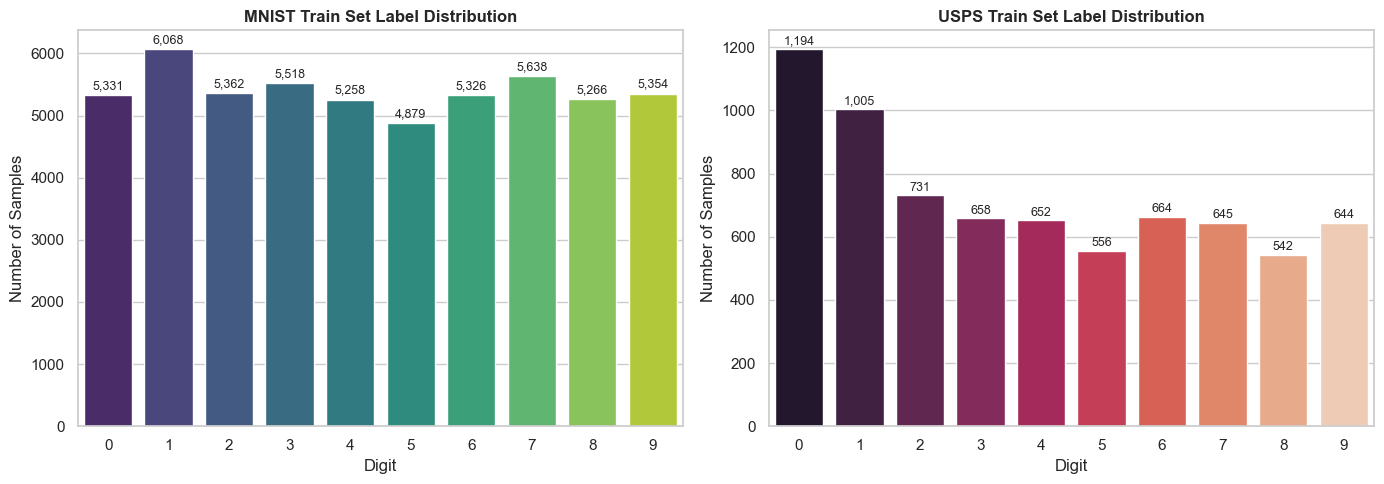

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot MNIST distribution
unique_m, counts_m = np.unique(y_train, return_counts=True)
sns.barplot(x=unique_m, y=counts_m, ax=axes[0], palette="viridis")
axes[0].set_title("MNIST Train Set Label Distribution", fontsize=12, fontweight='bold')
axes[0].set_xlabel("Digit")
axes[0].set_ylabel("Number of Samples")
for i, count in enumerate(counts_m):
    axes[0].text(i, count + 100, f"{count:,}", ha='center', fontsize=9)

# Plot USPS distribution
unique_u, counts_u = np.unique(y_usps_train, return_counts=True)
sns.barplot(x=unique_u, y=counts_u, ax=axes[1], palette="rocket")
axes[1].set_title("USPS Train Set Label Distribution", fontsize=12, fontweight='bold')
axes[1].set_xlabel("Digit")
axes[1].set_ylabel("Number of Samples")
for i, count in enumerate(counts_u):
    axes[1].text(i, count + 15, f"{count:,}", ha='center', fontsize=9)

plt.tight_layout()
plt.show()

### 3.3. Visualizing & Comparing Real Samples (MNIST vs. USPS)
Observe the image grid below. You will clearly see the **Domain Shift phenomenon**:
- **MNIST** (Top row): Thin strokes, perfectly centered, absolutely clean black background.
- **USPS** (Bottom row): Thicker strokes, blurry/fuzzy details, scanner noise from scanning real mail envelopes, and handwriting positions often shifted to the borders. This difference is why traditional machine learning models suffer a severe drop in accuracy when transferring across domains.

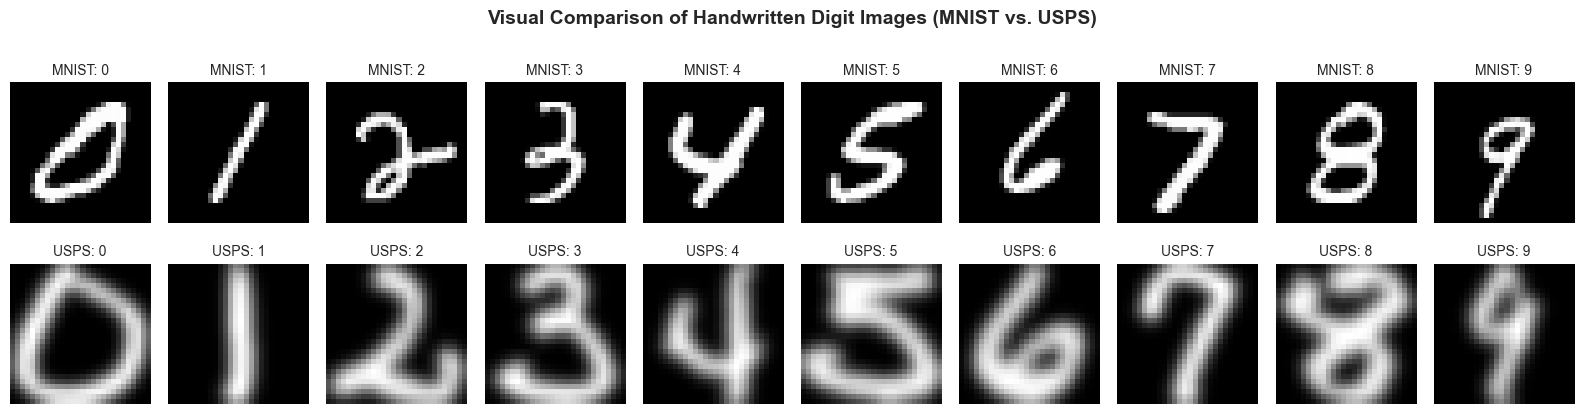

In [22]:
fig, axes = plt.subplots(2, 10, figsize=(16, 4.5))

for digit in range(10):
    m_idx = np.where(y_train == digit)[0][0]
    u_idx = np.where(y_usps_train == digit)[0][0]
    
    # Plot MNIST
    axes[0, digit].imshow(X_train[m_idx].reshape(28, 28), cmap='gray')
    axes[0, digit].axis('off')
    axes[0, digit].set_title(f"MNIST: {digit}", fontsize=10)
    
    # Plot USPS
    axes[1, digit].imshow(X_usps_train[u_idx].reshape(28, 28), cmap='gray')
    axes[1, digit].axis('off')
    axes[1, digit].set_title(f"USPS: {digit}", fontsize=10)

plt.suptitle("Visual Comparison of Handwritten Digit Images (MNIST vs. USPS)", fontsize=14, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

## 4. Data Augmentation Mechanism
### On-the-fly Operation:
- **No Static File Generation**: Transformations are not saved as files on disk, saving storage and memory. They are applied dynamically in RAM/GPU when batches of data are fed into the model.
- **Random Transformations**: During each training epoch, images are randomly rotated up to $\pm 28^\circ$, horizontally/vertically translated up to $8\%$, and zoomed up to $8\%$.
- **Preserves Evaluative Integrity**: This mechanism is active only during training (`training=True`). During evaluation/testing (`training=False`), these layers are automatically bypassed, preserving original test images.
- **Benefits**: Forces the neural network to learn invariant geometric features of digits (e.g., the loop of '0', the diagonal of '7') instead of memorizing static pixel locations of the MNIST training set.

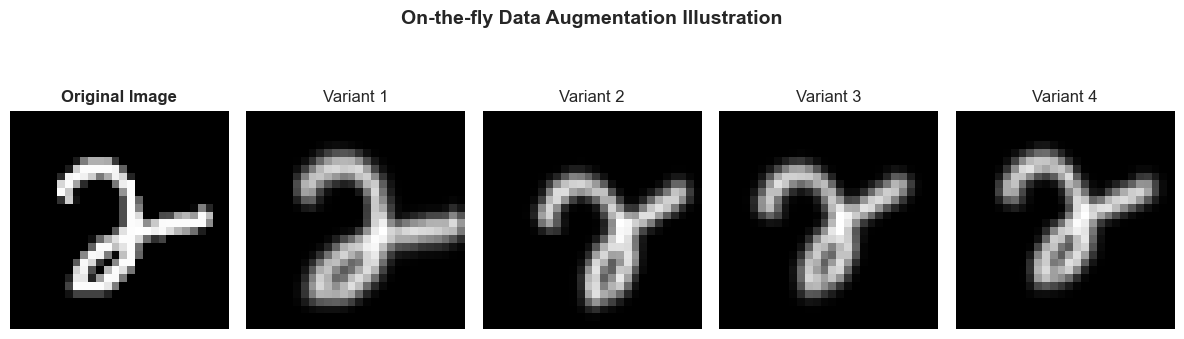

In [23]:
data_augmentation = tf.keras.Sequential([
    layers.RandomRotation(0.08, fill_mode='constant', fill_value=0.0),
    layers.RandomTranslation(0.08, 0.08, fill_mode='constant', fill_value=0.0),
    layers.RandomZoom(0.08, fill_mode='constant', fill_value=0.0)
])

sample_img = X_train[0]

plt.figure(figsize=(12, 4))
plt.subplot(1, 5, 1)
plt.imshow(sample_img.reshape(28, 28), cmap='gray')
plt.title("Original Image", fontweight='bold')
plt.axis('off')

for i in range(4):
    aug_img = data_augmentation(tf.expand_dims(sample_img, 0), training=True)
    plt.subplot(1, 5, i + 2)
    plt.imshow(np.array(aug_img[0]).reshape(28, 28), cmap='gray')
    plt.title(f"Variant {i+1}")
    plt.axis('off')
plt.suptitle("On-the-fly Data Augmentation Illustration", fontsize=14, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

## 5. Detailed Model Architectures
We define the architectures of the machine learning models here:
1. **Improved CNN**: Uses consecutive convolutional blocks with `Batch Normalization` layers to stabilize gradients, and `Dropout` layers ($25\%$ and $50\%$) to suppress overfitting.
2. **LeNet-5**: The classic convolutional neural network by Yann LeCun (1998), using `tanh` activations and average pooling as a baseline.
3. **Mini-ResNet**: A residual network using shortcut connections (Residual blocks) to add features directly, preserving gradients as depth increases.

In [24]:
def build_improved_cnn(input_shape=(28, 28, 1), num_classes=10):
    inputs = layers.Input(shape=input_shape)
    
    # Conv Block 1
    x = layers.Conv2D(32, (3, 3), padding='same')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Conv2D(32, (3, 3), padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Dropout(0.25)(x)
    
    # Conv Block 2
    x = layers.Conv2D(64, (3, 3), padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Conv2D(64, (3, 3), padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Dropout(0.25)(x)
    
    # Fully Connected Blocks for classification
    x = layers.Flatten()(x)
    x = layers.Dense(256)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Dropout(0.5)(x)
    
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    return models.Model(inputs=inputs, outputs=outputs, name="improved_cnn")

def build_lenet5(input_shape=(28, 28, 1), num_classes=10):
    inputs = layers.Input(shape=input_shape)
    x = layers.Conv2D(6, (5, 5), padding='same', activation='tanh')(inputs)
    x = layers.AveragePooling2D((2, 2))(x)
    x = layers.Conv2D(16, (5, 5), padding='valid', activation='tanh')(x)
    x = layers.AveragePooling2D((2, 2))(x)
    x = layers.Conv2D(120, (5, 5), padding='valid', activation='tanh')(x)
    x = layers.Flatten()(x)
    x = layers.Dense(84, activation='tanh')(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    return models.Model(inputs=inputs, outputs=outputs, name="lenet5")

def residual_block(input_tensor, filters):
    x = layers.Conv2D(filters, (3, 3), padding='same')(input_tensor)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Conv2D(filters, (3, 3), padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.add([x, input_tensor])
    return layers.Activation('relu')(x)

def build_mini_resnet(input_shape=(28, 28, 1), num_classes=10):
    inputs = layers.Input(shape=input_shape)
    x = layers.Conv2D(32, (3, 3), padding='same')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = residual_block(x, 32)
    
    x = layers.Conv2D(64, (3, 3), strides=(2, 2), padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = residual_block(x, 64)
    
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(128)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    return models.Model(inputs=inputs, outputs=outputs, name="mini_resnet")

## 6. Training Process & Smart Callbacks
We set up callbacks to control the optimization process:
- **ReduceLROnPlateau**: Reduces the learning rate when validation loss plateaus (no improvement after 2 epochs) to help the optimizer converge into deep local minima.
- **EarlyStopping**: Stops training early when validation loss does not decrease after 5 epochs to prevent overfitting.

> **Note**: To save experimental runtime, `TRAIN_FROM_SCRATCH = False` is set by default, so the program automatically loads pre-trained weight files from the `models/` folder. You can change this to `True` if you wish to run the training process from scratch and plot validation curves across Epochs.

In [25]:
TRAIN_FROM_SCRATCH = False

def create_callbacks():
    lr_scheduler = callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-5, verbose=1)
    early_stop = callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1)
    return [lr_scheduler, early_stop]

if TRAIN_FROM_SCRATCH:
    print("Starting CNN training on MNIST...")
    cnn_model = build_improved_cnn()
    cnn_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    
    # Data pipeline
    train_ds = tf.data.Dataset.from_tensor_slices((X_train, y_train)).shuffle(1024).batch(128)
    train_ds_aug = train_ds.map(lambda x, y: (data_augmentation(x, training=True), y), num_parallel_calls=tf.data.AUTOTUNE)
    val_ds = tf.data.Dataset.from_tensor_slices((X_val, y_val)).batch(128)
    
    history = cnn_model.fit(train_ds_aug, epochs=12, validation_data=val_ds, callbacks=create_callbacks())
    
    # Plot learning curves
    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.title("Loss Curve")
    plt.legend()
    
    plt.subplot(1, 2, 2)
    plt.plot(history.history['accuracy'], label='Train Acc')
    plt.plot(history.history['val_accuracy'], label='Val Acc')
    plt.title("Accuracy Curve")
    plt.legend()
    plt.show()
else:
    print("TRAIN_FROM_SCRATCH is False. Waiting to load model weights in the next step...")

TRAIN_FROM_SCRATCH is False. Waiting to load model weights in the next step...


### 6.1. SVM + PCA Training Illustration
The SVM model, learning non-linear boundaries via the RBF kernel, trains quickly (~80 seconds) after the dataset dimensionality is compressed from 784 to 50 principal components using PCA.

In [26]:
RUN_SVM_TRAINING = False

if RUN_SVM_TRAINING:
    print("Training PCA and SVM...")
    X_train_flat = X_train.reshape(X_train.shape[0], -1)
    X_val_flat = X_val.reshape(X_val.shape[0], -1)
    
    # Initialize PCA with 50 components
    pca_demo = PCA(n_components=50, random_state=42)
    X_train_pca = pca_demo.fit_transform(X_train_flat[:15000])  # Subsample 15k images for speed
    X_val_pca = pca_demo.transform(X_val_flat)
    
    # Fit SVM
    svm_demo = SVC(C=10, gamma=0.01, probability=True, random_state=42)
    svm_demo.fit(X_train_pca, y_train[:15000])
    
    # Measure validation accuracy
    preds = svm_demo.predict(X_val_pca)
    print(f"SVM Validation Accuracy: {accuracy_score(y_val, preds)*100:.2f}%")
else:
    print("Skipping SVM training. Pre-trained weights will be loaded below.")

Skipping SVM training. Pre-trained weights will be loaded below.


## 7. Cross-Domain Evaluation & Comprehensive Result Visualization
We load the saved weights, evaluate models directly on the USPS test set, and display a dual-bar comparison chart.

All models loaded successfully!

| Model        |   MNIST Accuracy (%) |   USPS Accuracy (%) |
|:-------------|---------------------:|--------------------:|
| Improved CNN |              99.1667 |             87.9422 |
| Mini-ResNet  |              98.75   |             78.0269 |
| LeNet-5      |              98.35   |             60.3388 |
| PCA + SVM    |              97.8667 |             44.9925 |


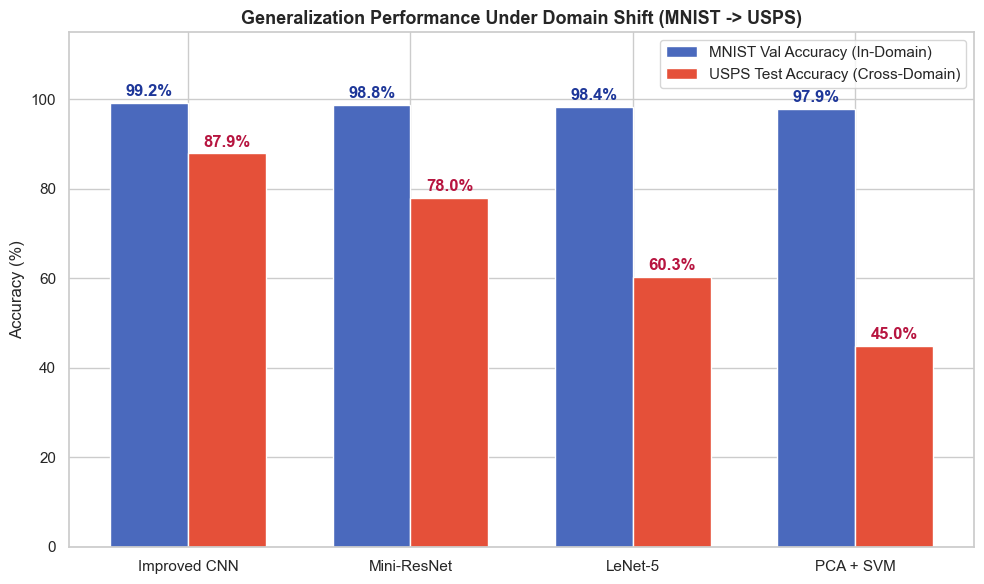

In [27]:
try:
    # Load models from disk
    cnn_model = tf.keras.models.load_model("models/improved_cnn.keras")
    lenet_model = tf.keras.models.load_model("models/lenet5.keras")
    resnet_model = tf.keras.models.load_model("models/mini_resnet.keras")

    with open("models/svm_model.pkl", "rb") as f:
        svm_model = pickle.load(f)
    with open("models/pca_model.pkl", "rb") as f:
        pca_model = pickle.load(f)
        
    print("All models loaded successfully!\n")
    
    # Evaluate CNN
    _, cnn_mnist_acc = cnn_model.evaluate(X_val, y_val, verbose=0)
    _, cnn_usps_acc = cnn_model.evaluate(X_usps_test, y_usps_test, verbose=0)
    
    # Evaluate LeNet-5
    _, lenet_mnist_acc = lenet_model.evaluate(X_val, y_val, verbose=0)
    _, lenet_usps_acc = lenet_model.evaluate(X_usps_test, y_usps_test, verbose=0)

    # Evaluate ResNet
    _, resnet_mnist_acc = resnet_model.evaluate(X_val, y_val, verbose=0)
    _, resnet_usps_acc = resnet_model.evaluate(X_usps_test, y_usps_test, verbose=0)
    
    # Evaluate SVM
    X_val_flat = X_val.reshape(X_val.shape[0], -1)
    X_val_pca = pca_model.transform(X_val_flat)
    svm_mnist_acc = svm_model.score(X_val_pca, y_val)
    
    X_usps_test_flat = X_usps_test.reshape(X_usps_test.shape[0], -1)
    X_usps_test_pca = pca_model.transform(X_usps_test_flat)
    svm_usps_acc = svm_model.score(X_usps_test_pca, y_usps_test)
    
    # Create Results DataFrame
    df_results = pd.DataFrame({
        'Model': ['Improved CNN', 'Mini-ResNet', 'LeNet-5', 'PCA + SVM'],
        'MNIST Accuracy (%)': [cnn_mnist_acc*100, resnet_mnist_acc*100, lenet_mnist_acc*100, svm_mnist_acc*100],
        'USPS Accuracy (%)': [cnn_usps_acc*100, resnet_usps_acc*100, lenet_usps_acc*100, svm_usps_acc*100]
    })
    
    # Display Markdown Table
    print(df_results.to_markdown(index=False))
    
    # Plot double bar chart for Domain Shift
    plt.figure(figsize=(10, 6))
    x = np.arange(len(df_results['Model']))
    width = 0.35
    
    plt.bar(x - width/2, df_results['MNIST Accuracy (%)'], width, label='MNIST Val Accuracy (In-Domain)', color='#4a69bd')
    plt.bar(x + width/2, df_results['USPS Accuracy (%)'], width, label='USPS Test Accuracy (Cross-Domain)', color='#e55039')
    
    plt.title("Generalization Performance Under Domain Shift (MNIST -> USPS)", fontsize=13, fontweight='bold')
    plt.xticks(x, df_results['Model'])
    plt.ylabel("Accuracy (%)")
    plt.ylim(0, 115)
    plt.legend()
    
    # Annotate column values
    for idx, val in enumerate(df_results['MNIST Accuracy (%)']):
        plt.text(idx - width/2, val + 1.5, f"{val:.1f}%", ha='center', fontweight='bold', color='#1e3799')
    for idx, val in enumerate(df_results['USPS Accuracy (%)']):
        plt.text(idx + width/2, val + 1.5, f"{val:.1f}%", ha='center', fontweight='bold', color='#b71540')
        
    plt.tight_layout()
    plt.show()

except Exception as e:
    print(f"An error occurred while loading and evaluating models: {e}")